
# RNN em Física: Séries temporais (manchas solares) usando RNN
## Alexandre Suaide

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Input
from keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler


I0000 00:00:1784802605.991046   65282 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784802605.991426   65282 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784802606.017570   65282 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784802606.850430   65282 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
# Funções necessárias

# def get_XY(data, time_steps):
#     Y_ind = np.arange(time_steps, len(data), time_steps)
#     Y = data[Y_ind]
#     rows_x = len(Y)
#     X = data[range(time_steps*rows_x)]
#     X = np.reshape(X, (rows_x, time_steps, 1))    
#     return X, Y

def get_XY(data, time_steps):
    X = []
    Y = []

    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        Y.append(data[i+time_steps])

    X = np.array(X).reshape(-1, time_steps, 1)
    Y = np.array(Y)

    return X, Y

In [3]:
# Carrega o dataset

df = pd.read_csv("manchas-solares.csv")
df.head()

,Month,Sunspots
0,1749-01,58.0
1,1749-02,62.6
2,1749-03,70.0
3,1749-04,55.7
4,1749-05,85.0


In [4]:
# Converte em uma sequência

data = np.array(df['Sunspots'].values.astype('float32')).reshape(-1, 1)
data

array([[58. ],
       [62.6],
       [70. ],
       ...,
       [55.8],
       [33.3],
       [33.4]], dtype=float32)

In [5]:
# Escalona os dados entre 0 e 1

scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data)
data.shape

(2820, 1)

In [6]:
# Divide a sequência entre treino e predição

fraction = 0.6
n = len(data)
split = int(fraction * n) # 80% train, 20% test
train = data[range(split)]
test = data[split:]

In [7]:
train.shape

(1692, 1)

In [8]:
test.shape

(1128, 1)

In [9]:
# Divide a sequência em subconjuntos de steps

steps = 12
train_x, train_y = get_XY(train,steps)
test_x, test_y = get_XY(test,steps)
train_x.shape


(1680, 12, 1)

In [10]:
# Construção do modelo no Keras

model = Sequential()
model.add(Input(shape=train_x.shape[1:]))
model.add(SimpleRNN(units = 3, activation = 'tanh'))
model.add(Dense(units = 1, activation = 'tanh'))
        
optimizer = Adam()

model.compile(optimizer = optimizer , loss = "MSE", metrics=["accuracy"])
model.summary()

E0000 00:00:1784802607.629530   65282 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (76.00 B)

 Trainable params: 19 (76.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Treina a rede

epochs = 30
batch_size = 1
history = model.fit(train_x, train_y, epochs = epochs, batch_size = batch_size)

Epoch 1/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0357 - loss: 0.0061
Epoch 2/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0357 - loss: 0.0045
Epoch 3/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0357 - loss: 0.0041
Epoch 4/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0357 - loss: 0.0039
Epoch 5/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0357 - loss: 0.0038
Epoch 6/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0357 - loss: 0.0038
Epoch 7/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0357 - loss: 0.0038
Epoch 8/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0357 - loss: 0.0038
Epoch 9/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0357 - loss: 0.0037
Epoch 10/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0357 - loss: 0.0037
Epoch 11/30
1680/1680 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0357 - loss: 0.0037
Epoch 12/30
1680/1680 ━━━━━━━━

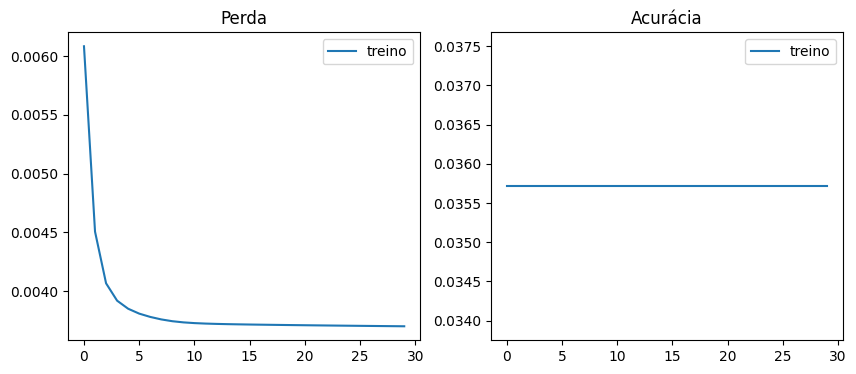

In [12]:
# faz figura da perda e da acurácia para cada época

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='treino')
plt.title('Perda')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='treino')
plt.title('Acurácia')
plt.legend()
plt.show()

In [13]:
# Realiza as previsões, tanto para o período de treino quando para o período de teste

train_predict = model.predict(train_x)
test_predict = model.predict(test_x)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [14]:
full_y = np.append(train_y, test_y)
full_p = np.append(train_predict, test_predict)

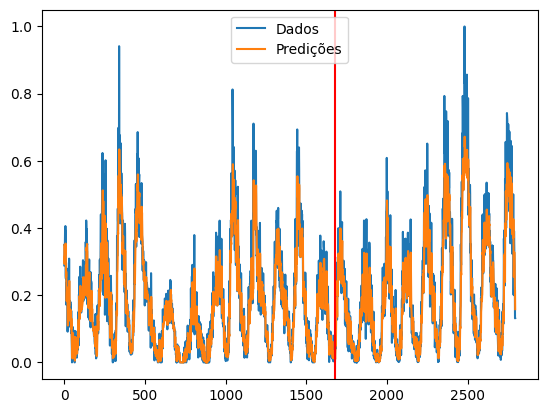

In [15]:
# Faz a figura

plt.figure()
plt.plot(full_y)
plt.plot(full_p)
plt.axvline(x=len(train_y), color='r')
plt.legend(['Dados', 'Predições'])

In [16]:
# salva o modelo para uso futuro em novos dados. Dai não precisa treinar a rede novamente

model.save("manchas_solares.keras")
print("Modelo gravado como manchas_solares.keras")

Modelo gravado como manchas_solares.keras
